# Reconstruction de la série mensuelle

**Projet data PSL-CFX** — Hôpitaux universitaires Pitié-Salpêtrière / Charles-Foix

## Objectif

Construire la série **mensuelle** qui servira à entraîner le modèle SARIMA, en
combinant deux briques déjà produites :

| Brique | Fichier | Apporte |
|--------|---------|---------|
| Niveau d'activité | `data/processed/serie_annuelle.csv` | Les totaux annuels réels du groupe hospitalier |
| Forme saisonnière | `data/processed/profil_saisonnier.csv` | La répartition mensuelle mesurée sur les données DREES |

Les rapports annuels ne publient qu'un total par an : impossible d'en tirer
directement une série mensuelle. Le profil DREES fournit la forme, les rapports
fournissent le niveau.

**Aucun pourcentage mensuel n'est écrit en dur dans ce notebook** : la répartition
provient exclusivement de `profil_saisonnier.csv`.

## Déroulé

1. Interpolation linéaire des années manquantes (2013 et 2014 principalement)
2. Mensualisation des indicateurs d'activité, avec contrôle de conservation des totaux
3. Graphiques distinguant les mois issus d'années interpolées
4. Méthode et limites

## 1. Chargement

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter

%matplotlib inline


def trouver_racine(depart: Path) -> Path:
    """Remonte l'arborescence jusqu'au dossier contenant requirements.txt."""
    for dossier in [depart, *depart.parents]:
        if (dossier / "requirements.txt").exists():
            return dossier
    raise RuntimeError("Racine du projet introuvable")


RACINE = trouver_racine(Path.cwd())
DOSSIER_TRAITE = RACINE / "data" / "processed"

MOIS_COURTS = ["Janv.", "Févr.", "Mars", "Avr.", "Mai", "Juin",
               "Juil.", "Août", "Sept.", "Oct.", "Nov.", "Déc."]
MOIS_LONGS = ["janvier", "février", "mars", "avril", "mai", "juin",
              "juillet", "août", "septembre", "octobre", "novembre", "décembre"]

serie_annuelle = pd.read_csv(DOSSIER_TRAITE / "serie_annuelle.csv")
profil = pd.read_csv(DOSSIER_TRAITE / "profil_saisonnier.csv")

print(f"serie_annuelle.csv    : {len(serie_annuelle)} lignes, "
      f"{serie_annuelle['INDICATEUR'].nunique()} indicateurs")
print(f"profil_saisonnier.csv : {len(profil)} lignes")
profil

serie_annuelle.csv    : 33 lignes, 9 indicateurs
profil_saisonnier.csv : 12 lignes


,MOIS,PCT_NORMAL,PASSAGES_MOYENS_PAR_JOUR
0,1,8.6513,2578.90
1,2,7.6610,2528.21
2,3,8.5417,2545.97
3,4,8.1369,2506.56
4,5,8.4745,2525.65
5,6,8.4457,2600.81
6,7,8.1175,2419.75
7,8,7.1866,2141.84
8,9,8.1259,2502.85
9,10,8.9770,2675.40


## 2. Interpolation des années manquantes

Les rapports disponibles couvrent 2011, 2012, 2015 et 2016 : **2013 et 2014 sont
absentes**. On les reconstitue par **interpolation linéaire**, indicateur par
indicateur.

Deux règles :

- **Pas d'extrapolation.** On ne comble qu'entre la première et la dernière année
  observée d'un indicateur. « Urgences (SAU) » s'arrête en 2015 faute de valeur
  exploitable en 2016 : la série s'arrête donc en 2015, on n'invente pas 2016.
- **Traçabilité.** Une colonne `INTERPOLE` distingue les valeurs mesurées des valeurs
  reconstituées, pour qu'aucune lecture ultérieure ne les confonde.

In [2]:
def interpoler_indicateur(groupe: pd.DataFrame) -> pd.DataFrame:
    """Complète les années manquantes d'un indicateur par interpolation linéaire.

    L'interpolation est bornée aux années observées : aucune extrapolation avant la
    première ni après la dernière année disponible.
    """
    valeurs = groupe.set_index("ANNEE")["VALEUR"].sort_index()
    annees_observees = set(valeurs.index)

    # Grille continue entre la première et la dernière année observée
    grille = range(int(valeurs.index.min()), int(valeurs.index.max()) + 1)

    # method="index" interpole selon les valeurs de l'index (les années), et non
    # selon la position des lignes : correct même si les trous sont irréguliers.
    completee = valeurs.reindex(grille).interpolate(method="index")

    resultat = completee.reset_index()
    resultat.columns = ["ANNEE", "VALEUR"]
    resultat["INDICATEUR"] = groupe["INDICATEUR"].iloc[0]
    resultat["INTERPOLE"] = ~resultat["ANNEE"].isin(annees_observees)
    resultat["COMPARABLE"] = bool(groupe["COMPARABLE"].iloc[0])
    return resultat


serie_complete = pd.concat(
    [interpoler_indicateur(groupe) for _, groupe in serie_annuelle.groupby("INDICATEUR")],
    ignore_index=True,
)
serie_complete = serie_complete[["ANNEE", "INDICATEUR", "VALEUR", "INTERPOLE", "COMPARABLE"]]
serie_complete = serie_complete.sort_values(["INDICATEUR", "ANNEE"]).reset_index(drop=True)

# Récapitulatif : années observées et années reconstituées, indicateur par indicateur
print(f"{len(serie_annuelle)} observations -> {len(serie_complete)} lignes après interpolation\n")
for nom, groupe in serie_complete.groupby("INDICATEUR"):
    observees = groupe.loc[~groupe["INTERPOLE"], "ANNEE"].tolist()
    interpolees = groupe.loc[groupe["INTERPOLE"], "ANNEE"].tolist()
    ajout = f" + {interpolees} interpolée(s)" if interpolees else " (rien à interpoler)"
    print(f"{nom:35s} {observees}{ajout}")

33 observations -> 51 lignes après interpolation

Consultations externes              [2011, 2012, 2015, 2016] + [2013, 2014] interpolée(s)
Journées PSY                        [2011, 2012, 2015, 2016] + [2013, 2014] interpolée(s)
Journées SLD                        [2011, 2012, 2015, 2016] + [2013, 2014] interpolée(s)
Journées SSR                        [2011, 2012, 2015, 2016] + [2013, 2014] interpolée(s)
Lits installés                      [2012, 2015, 2016] + [2013, 2014] interpolée(s)
Séjours ambulatoires                [2011, 2012, 2015, 2016] + [2013, 2014] interpolée(s)
Séjours hospitalisation complète    [2011, 2012, 2015, 2016] + [2013, 2014] interpolée(s)
Transplantations                    [2012, 2015, 2016] + [2013, 2014] interpolée(s)
Urgences (SAU)                      [2011, 2012, 2015] + [2013, 2014] interpolée(s)


In [3]:
# Contrôles avant enregistrement
assert serie_complete["VALEUR"].notna().all(), "Valeurs manquantes après interpolation"

# Les valeurs observées ne doivent pas avoir bougé d'un iota
fusion = serie_annuelle.merge(
    serie_complete, on=["ANNEE", "INDICATEUR"], suffixes=("_origine", "_complete")
)
assert np.allclose(fusion["VALEUR_origine"], fusion["VALEUR_complete"]), \
    "L'interpolation a modifié des valeurs observées"
assert not fusion["INTERPOLE"].any(), "Une valeur observée est marquée comme interpolée"

destination = DOSSIER_TRAITE / "serie_annuelle_complete.csv"
serie_complete.to_csv(destination, index=False, encoding="utf-8")
print(f"Écrit dans {destination.relative_to(RACINE)} ({len(serie_complete)} lignes)")

serie_complete[serie_complete["INDICATEUR"] == "Urgences (SAU)"]

Écrit dans data\processed\serie_annuelle_complete.csv (51 lignes)


,ANNEE,INDICATEUR,VALEUR,INTERPOLE,COMPARABLE
46,2011,Urgences (SAU),83002.000000,False,False
47,2012,Urgences (SAU),85993.000000,False,False
48,2013,Urgences (SAU),77019.333333,True,False
49,2014,Urgences (SAU),68045.666667,True,False
50,2015,Urgences (SAU),59072.000000,False,False


## 3. Mensualisation

La valeur d'un mois vaut : **total annuel × part du mois**, la part venant du profil
saisonnier mesuré.

### Une précision nécessaire sur les parts

`PCT_NORMAL` est enregistré arrondi à quatre décimales, si bien que la somme des douze
parts vaut 99,9999 % et non 100 %. Utilisée telle quelle, la répartition perdrait une
fraction du total annuel — environ 7 consultations sur 660 000, négligeable en valeur
mais suffisant pour faire échouer un contrôle de conservation exact.

On **renormalise** donc les parts pour qu'elles somment exactement à 1. Ce n'est pas
une modification du profil mesuré : c'est la correction de son arrondi d'écriture. Les
proportions relatives entre les mois sont strictement conservées.

In [4]:
# Poids mensuels issus EXCLUSIVEMENT du profil saisonnier mesuré
poids = profil.set_index("MOIS")["PCT_NORMAL"].sort_index()

print(f"Somme des parts telles qu'enregistrées : {poids.sum():.6f} %")
poids_normalises = poids / poids.sum()          # somme exactement égale à 1
print(f"Somme après renormalisation            : {poids_normalises.sum():.12f}")

# On vérifie que la renormalisation n'a pas déformé le profil
ecart_relatif_max = ((poids_normalises * 100 - poids) / poids).abs().max()
print(f"Déformation relative maximale du profil : {ecart_relatif_max:.2e}")

assert len(poids_normalises) == 12, "Le profil doit couvrir 12 mois"
assert np.isclose(poids_normalises.sum(), 1.0), "Les poids doivent sommer à 1"

Somme des parts telles qu'enregistrées : 99.999900 %
Somme après renormalisation            : 1.000000000000
Déformation relative maximale du profil : 1.00e-06


In [5]:
# Seuls les indicateurs de flux d'activité sont mensualisés. Les indicateurs de
# stock (lits installés) ou d'événements rares (transplantations) ne se répartissent
# pas avec un profil de fréquentation des urgences.
INDICATEURS_MENSUALISES = [
    "Séjours hospitalisation complète",
    "Séjours ambulatoires",
    "Consultations externes",
    "Urgences (SAU)",
]

lignes_mensuelles = []

for _, ligne in serie_complete[
    serie_complete["INDICATEUR"].isin(INDICATEURS_MENSUALISES)
].iterrows():
    for mois in range(1, 13):
        lignes_mensuelles.append({
            "DATE": pd.Timestamp(year=int(ligne["ANNEE"]), month=mois, day=1),
            "ANNEE": int(ligne["ANNEE"]),
            "MOIS": mois,
            "INDICATEUR": ligne["INDICATEUR"],
            "VALEUR": ligne["VALEUR"] * poids_normalises[mois],
            "INTERPOLE": bool(ligne["INTERPOLE"]),
        })

serie_mensuelle = pd.DataFrame(lignes_mensuelles)
serie_mensuelle = serie_mensuelle.sort_values(["INDICATEUR", "DATE"]).reset_index(drop=True)

print(f"{len(serie_mensuelle)} lignes mensuelles")
print(f"{serie_mensuelle['INDICATEUR'].nunique()} indicateurs, "
      f"de {serie_mensuelle['DATE'].min():%m/%Y} à {serie_mensuelle['DATE'].max():%m/%Y}")
serie_mensuelle.head(6)

276 lignes mensuelles
4 indicateurs, de 01/2011 à 12/2016


,DATE,ANNEE,MOIS,INDICATEUR,VALEUR,INTERPOLE
0,2011-01-01,2011,1,Consultations externes,54809.154777,False
1,2011-02-01,2011,2,Consultations externes,48535.241495,False
2,2011-03-01,2011,3,Consultations externes,54114.798627,False
3,2011-04-01,2011,4,Consultations externes,51550.242334,False
4,2011-05-01,2011,5,Consultations externes,53689.062009,False
5,2011-06-01,2011,6,Consultations externes,53506.603459,False


### Contrôle obligatoire : conservation des totaux annuels

Pour chaque couple (indicateur, année), la somme des douze mois doit redonner le total
annuel. Le contrôle est fait par `assert` : si la reconstruction perdait ou créait de
l'activité, le notebook s'arrêterait ici.

In [6]:
sommes = (
    serie_mensuelle.groupby(["INDICATEUR", "ANNEE"])["VALEUR"].sum().rename("SOMME_MOIS")
)
reference = serie_complete.set_index(["INDICATEUR", "ANNEE"])["VALEUR"].rename("TOTAL_ANNUEL")

controle = pd.concat([reference, sommes], axis=1, join="inner")
controle["ECART"] = controle["SOMME_MOIS"] - controle["TOTAL_ANNUEL"]
controle["ECART_RELATIF"] = controle["ECART"] / controle["TOTAL_ANNUEL"]

ecart_max = controle["ECART"].abs().max()
ecart_relatif_max = controle["ECART_RELATIF"].abs().max()

print(f"{len(controle)} couples (indicateur, année) contrôlés")
print(f"Écart absolu maximal  : {ecart_max:.10f}")
print(f"Écart relatif maximal : {ecart_relatif_max:.2e}")

# Tolérance limitée à l'imprécision des flottants, pas à une approximation de méthode.
assert np.allclose(controle["SOMME_MOIS"], controle["TOTAL_ANNUEL"], rtol=1e-9, atol=1e-6), \
    "La somme des mois ne redonne pas le total annuel"

print("\nConservation des totaux vérifiée : la mensualisation ne crée ni ne perd d'activité.")
controle.round(2).head(8)

23 couples (indicateur, année) contrôlés
Écart absolu maximal  : 0.0000000001
Écart relatif maximal : 2.46e-16

Conservation des totaux vérifiée : la mensualisation ne crée ni ne perd d'activité.


TOTAL_ANNUEL  SOMME_MOIS  ECART  ECART_RELATIF
INDICATEUR             ANNEE                                                
Consultations externes 2011      633536.00   633536.00   -0.0           -0.0
                       2012      660958.00   660958.00   -0.0           -0.0
                       2013      643288.67   643288.67   -0.0           -0.0
                       2014      625619.33   625619.33   -0.0           -0.0
                       2015      607950.00   607950.00   -0.0           -0.0
                       2016      644602.00   644602.00   -0.0           -0.0
Séjours ambulatoires   2011       84911.00    84911.00   -0.0           -0.0
                       2012       87713.00    87713.00   -0.0           -0.0

In [7]:
destination = DOSSIER_TRAITE / "serie_mensuelle.csv"

sortie = serie_mensuelle.copy()
sortie["DATE"] = sortie["DATE"].dt.strftime("%Y-%m-%d")
sortie["VALEUR"] = sortie["VALEUR"].round(2)
sortie.to_csv(destination, index=False, encoding="utf-8")

print(f"Écrit dans {destination.relative_to(RACINE)}")
print(f"{len(sortie)} lignes | colonnes : {', '.join(sortie.columns)}")
print(f"\nRépartition observé / interpolé :")
print(sortie["INTERPOLE"].value_counts().rename({False: "observé", True: "interpolé"}).to_string())

Écrit dans data\processed\serie_mensuelle.csv
276 lignes | colonnes : DATE, ANNEE, MOIS, INDICATEUR, VALEUR, INTERPOLE

Répartition observé / interpolé :
INTERPOLE
observé      180
interpolé     96


## 4. Graphiques

### Série mensuelle des urgences

Les mois issus d'années interpolées sont tracés en tirets orange, sur fond grisé. La
série s'arrête en décembre 2015 : 2016 ne fournit pas de valeur SAU isolable, et on
s'interdit d'extrapoler.

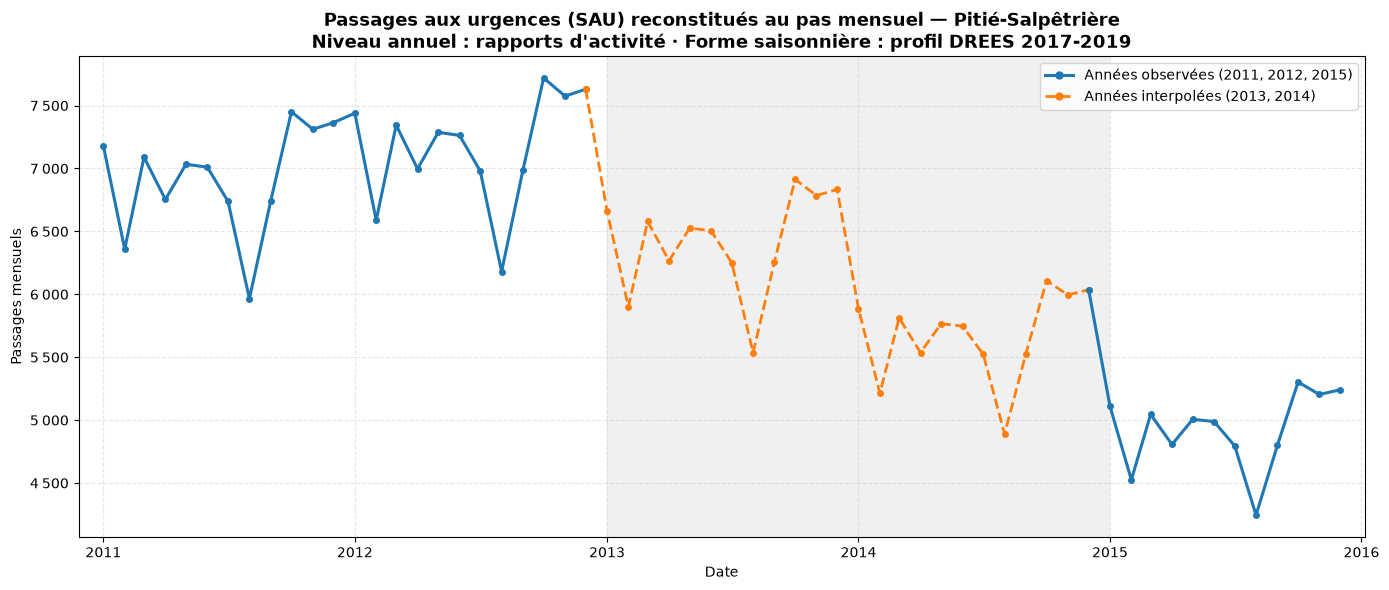

In [8]:
formateur_milliers = FuncFormatter(lambda v, _: f"{v:,.0f}".replace(",", "\u202f"))

BLEU = "#1f77b4"
ORANGE = "#ff7f0e"

urgences = serie_mensuelle[serie_mensuelle["INDICATEUR"] == "Urgences (SAU)"].copy()

fig, ax = plt.subplots(figsize=(14, 6))

# Fond grisé sur les années reconstituées, pour que la zone soit lisible d'un coup d'œil
annees_interpolees = sorted(urgences.loc[urgences["INTERPOLE"], "ANNEE"].unique())
for annee in annees_interpolees:
    ax.axvspan(pd.Timestamp(annee, 1, 1), pd.Timestamp(annee, 12, 31),
               color="#f0f0f0", zorder=0)

# La courbe est tracée par segments consécutifs de même statut, afin que le style
# change exactement à la frontière entre années observées et interpolées.
urgences = urgences.sort_values("DATE").reset_index(drop=True)
bloc = (urgences["INTERPOLE"] != urgences["INTERPOLE"].shift()).cumsum()

for _, segment in urgences.groupby(bloc):
    interpole = bool(segment["INTERPOLE"].iloc[0])
    indices = segment.index
    # On rattache le segment au point précédent pour éviter une rupture visuelle
    if indices[0] > 0:
        segment = urgences.loc[[indices[0] - 1, *indices]]
    ax.plot(segment["DATE"], segment["VALEUR"],
            color=ORANGE if interpole else BLEU,
            linestyle="--" if interpole else "-",
            linewidth=2.2 if not interpole else 2.0,
            marker="o", markersize=4, zorder=3)

ax.set_title(
    "Passages aux urgences (SAU) reconstitués au pas mensuel — Pitié-Salpêtrière\n"
    "Niveau annuel : rapports d'activité · Forme saisonnière : profil DREES 2017-2019",
    fontsize=13, fontweight="bold",
)
ax.set_xlabel("Date")
ax.set_ylabel("Passages mensuels")
ax.yaxis.set_major_formatter(formateur_milliers)
ax.grid(alpha=0.3, linestyle="--")
ax.margins(x=0.02)

legende = [
    Line2D([0], [0], color=BLEU, linewidth=2.2, marker="o", markersize=5,
           label="Années observées (2011, 2012, 2015)"),
    Line2D([0], [0], color=ORANGE, linewidth=2.0, linestyle="--", marker="o", markersize=5,
           label=f"Années interpolées ({', '.join(str(a) for a in annees_interpolees)})"),
]
ax.legend(handles=legende, fontsize=10, loc="upper right")

plt.tight_layout()
plt.show()

### Zoom sur une année observée

On isole 2012, année mesurée et non interpolée, pour lire la forme saisonnière seule,
débarrassée de la tendance pluriannuelle.

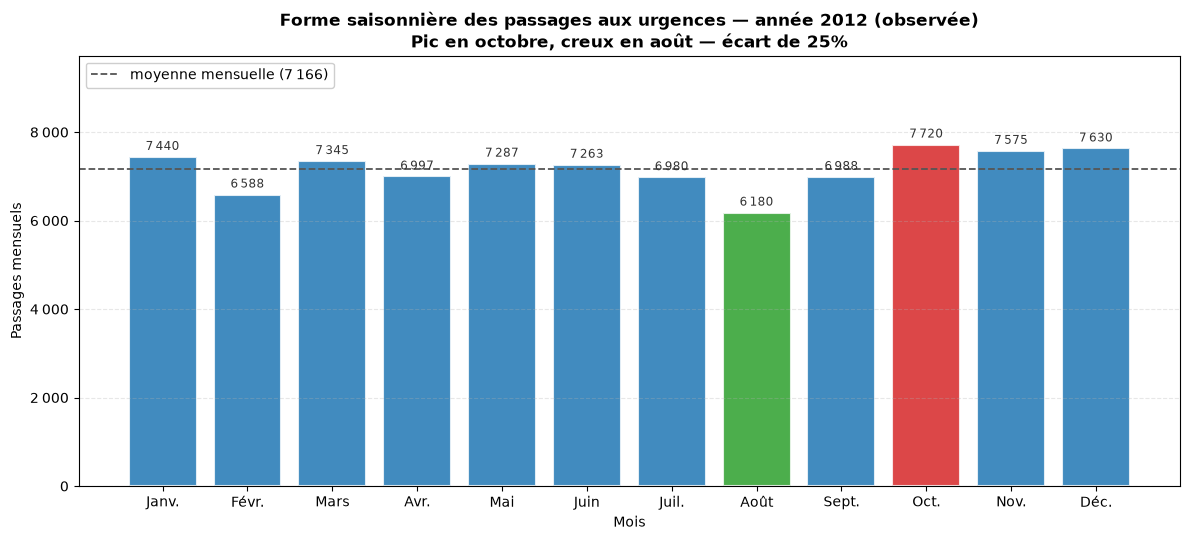

In [9]:
ANNEE_ZOOM = 2012

zoom = urgences[urgences["ANNEE"] == ANNEE_ZOOM].sort_values("MOIS")
assert not zoom["INTERPOLE"].any(), f"{ANNEE_ZOOM} devait être une année observée"

# Les extrêmes sont relus sur les données, jamais supposés
mois_pic = int(zoom.loc[zoom["VALEUR"].idxmax(), "MOIS"])
mois_creux = int(zoom.loc[zoom["VALEUR"].idxmin(), "MOIS"])
moyenne_mensuelle = zoom["VALEUR"].mean()

fig, ax = plt.subplots(figsize=(12, 5.5))

couleurs = ["#d62728" if m == mois_pic else "#2ca02c" if m == mois_creux else BLEU
            for m in zoom["MOIS"]]
ax.bar(zoom["MOIS"], zoom["VALEUR"], color=couleurs, alpha=0.85,
       edgecolor="white", linewidth=1.5)
ax.axhline(moyenne_mensuelle, color="#555555", linestyle="--", linewidth=1.3,
           label=f"moyenne mensuelle ({moyenne_mensuelle:,.0f})".replace(",", "\u202f"))

for mois, valeur in zip(zoom["MOIS"], zoom["VALEUR"]):
    ax.annotate(f"{valeur:,.0f}".replace(",", "\u202f"), xy=(mois, valeur),
                xytext=(0, 5), textcoords="offset points", ha="center", fontsize=8.5,
                color="#333333")

ecart = zoom["VALEUR"].max() / zoom["VALEUR"].min() - 1
ax.set_title(
    f"Forme saisonnière des passages aux urgences — année {ANNEE_ZOOM} (observée)\n"
    f"Pic en {MOIS_LONGS[mois_pic - 1]}, creux en {MOIS_LONGS[mois_creux - 1]} "
    f"— écart de {ecart:.0%}",
    fontsize=12.5, fontweight="bold",
)
ax.set_xlabel("Mois")
ax.set_ylabel("Passages mensuels")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(MOIS_COURTS)
ax.yaxis.set_major_formatter(formateur_milliers)
ax.margins(y=0.26)
# En haut à gauche : toute position basse chevaucherait les barres, qui partent de 0.
ax.legend(fontsize=10, loc="upper left", framealpha=0.95)
ax.grid(axis="y", alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

## 5. Méthode et limites

**Ce que fait cette reconstruction.** Elle croise deux sources : le **niveau** annuel
vient des rapports d'activité du groupe hospitalier, la **forme** mensuelle vient du
profil DREES mesuré sur Paris en 2017-2019. Aucun pourcentage n'a été inventé.

**Le profil est départemental, appliqué à un établissement.** On suppose que la
saisonnalité des urgences de la Pitié-Salpêtrière ressemble à celle de l'ensemble des
services parisiens. L'hypothèse est raisonnable — la saisonnalité des urgences tient à
des facteurs collectifs (viroses hivernales, départs en vacances d'été) qui touchent
tous les établissements d'un même bassin — mais elle reste une hypothèse, non une
mesure sur l'hôpital lui-même.

**Le profil est mesuré sur 2017-2019 et appliqué à 2011-2016.** On suppose donc aussi
que la forme saisonnière est stable dans le temps. C'est le meilleur choix disponible :
aucune source à pas fin ne couvre les années antérieures à 2017.

**Les années 2013 et 2014 sont interpolées.** Sur ces deux années, seule la *forme*
saisonnière est informative : le *niveau* est une estimation linéaire entre 2012 et
2015, pas une observation. Toute lecture de ces mois doit le rappeler.

**La série des urgences mélange des périmètres différents** (`COMPARABLE = False`) :
2011 et 2012 comptent les passages hors dentaires, 2015 le seul SAU. Les niveaux ne
sont donc pas comparables d'une année à l'autre, et la tendance à la baisse visible sur
le graphique est un artefact de périmètre, pas une réalité. **Cette série sert à
modéliser la dynamique saisonnière, pas les niveaux absolus.** Une prévision de volume
en passages devra s'appuyer sur les données DREES elles-mêmes, pas sur cette
reconstruction.